
# Attention R2 U-Net notebook

Notebook workflow for training/visualizing UNet variants (with Attention R2 U-Net default):
- Hot-reload project modules, use tqdm progress bars.
- Live SVG plots of train/val loss and inline sample predictions each epoch.
- Checkpoints (best + last) saved to `runs/notebook_demo/`.
- Final result graphs and saved samples accessible after training.


In [1]:
%load_ext autoreload
%autoreload 2
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
%matplotlib inline


In [2]:
# Set cwd to project root (handles notebooks where __file__ is undefined)
from pathlib import Path
import os

# Resolve the notebook file if available; otherwise use current working directory and assume we're in notebooks/
try:
    here = Path(__file__).resolve()
    root = here.parent.parent
except NameError:
    root = Path.cwd().parent

os.chdir(root)
print('cwd ->', Path.cwd())


cwd -> /home/jwwang/workspace/github/deep-learning-pj


In [3]:
import sys, os
sys.path.append(os.getcwd())

from __future__ import annotations

import json
import os
import csv
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Literal

import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import DataLoader
import torchvision.utils as vutils

import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # nice progress bars in notebook

from helpers.coco_dataset import CocoPaths, CocoSegmentationDataset, make_transforms
from unet import (
    AttentionR2UNet,
    AttentionUNet,
    R2UNet,
    UNet,
    init_weights,
)

ModelName = Literal["unet", "r2unet", "attunet", "attr2unet"]

In [4]:
@dataclass
class TrainConfig:
    data_root: Path
    save_dir: Path
    
    model: ModelName = "attr2unet"
    t: int = 2
    
    aug_mode: str = "light"           # "none" | "light" | "strong"
    aug_jitter_strength: float = 0.3
    
    batch_size: int = 4
    num_workers: int = 4
    lr: float = 1e-3
    weight_decay: float = 1e-5
    num_epochs: int = 100
    num_epochs_decay: int = 20
    
    log_every: int = 25
    amp: bool = True
    compile: bool = False
    resume: Path | None = None
    
    image_size: int = 256
    coco_json: Path | None = None
    masks_dir: Path | None = None
    images_dir: Path | None = None
    
    sample_every: int = 0  # steps between sample dumps (0 to disable)
    sample_dir: Path | None = None
    sample_count: int = 3
    
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    img_ch: int = 3
    output_ch: int = 1
    
    gpu_ids: list[int] | None = None

In [5]:
def build_model(cfg: TrainConfig) -> nn.Module:
    if cfg.model == "unet":
        model = UNet(img_ch=cfg.img_ch, output_ch=cfg.output_ch)
    elif cfg.model == "r2unet":
        model = R2UNet(img_ch=cfg.img_ch, output_ch=cfg.output_ch, t=cfg.t)
    elif cfg.model == "attunet":
        model = AttentionUNet(img_ch=cfg.img_ch, output_ch=cfg.output_ch)
    elif cfg.model == "attr2unet":
        model = AttentionR2UNet(img_ch=cfg.img_ch, output_ch=cfg.output_ch, t=cfg.t)
    else:
        raise ValueError(f"Unknown model type: {cfg.model}")
    init_weights(model, init_type="kaiming")
    if cfg.compile:
        model = torch.compile(model)
    return model


def dice_loss(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2, 3))
    denominator = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return 1 - dice.mean()


In [6]:
def save_checkpoint(model: nn.Module, optimizer: optim.Optimizer, scheduler: optim.lr_scheduler, epoch: int, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    # Handle DataParallel
    if isinstance(model, torch.nn.DataParallel):
        model_state = model.module.state_dict()
    else:
        model_state = model.state_dict()

    torch.save(
        {
            "epoch": epoch,
            "model_state": model_state,
            "optim_state": optimizer.state_dict(),
            "sched_state": scheduler.state_dict(),
        },
        path,
    )

def save_debug_samples(
    images: torch.Tensor,
    masks: torch.Tensor,
    preds: torch.Tensor,
    out_dir: Path,
    tag: str,
    max_samples: int = 3,
) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    images = images[:max_samples].cpu()
    masks = masks[:max_samples].cpu()
    preds = preds[:max_samples].cpu()

    # Make sure spatial dims match (padding can introduce small differences)
    if preds.shape[-2:] != images.shape[-2:]:
        preds = torch.nn.functional.interpolate(preds, size=images.shape[-2:], mode="nearest")
    if masks.shape[-2:] != images.shape[-2:]:
        masks = torch.nn.functional.interpolate(masks, size=images.shape[-2:], mode="nearest")

    preds_bin = (preds > 0.5).float()

    vutils.save_image(images, out_dir / f"{tag}_images.png", nrow=max_samples, normalize=True)
    vutils.save_image(masks, out_dir / f"{tag}_masks.png", nrow=max_samples)
    vutils.save_image(preds_bin, out_dir / f"{tag}_preds.png", nrow=max_samples)

    # Overlay: image + red prediction
    overlay = images.clone()
    if overlay.shape[1] == 3:
        overlay[:, 0, :, :] = torch.clamp(overlay[:, 0, :, :] + preds_bin.squeeze(1), 0, 1)
    vutils.save_image(overlay, out_dir / f"{tag}_overlay.png", nrow=max_samples, normalize=True)


In [7]:
def list_available_gpus() -> list[int]:
    """
    Print and return a list of available CUDA device indices.
    """
    if not torch.cuda.is_available():
        print("No CUDA device available. Using CPU.")
        return []

    num = torch.cuda.device_count()
    indices: list[int] = []
    print(f"Found {num} CUDA device(s):")
    for i in range(num):
        props = torch.cuda.get_device_properties(i)
        mem_gb = props.total_memory / (1024 ** 3)
        print(f"  [{i}] {props.name} - {mem_gb:.1f} GB")
        indices.append(i)
    return indices


def select_gpus(
    mode: str = "all",
    indices: list[int] | None = None,
) -> tuple[torch.device, list[int]]:
    """
    mode:
      - 'all': use all visible GPUs
      - 'first': use GPU 0 only
      - 'indices': use specific gpu indices (provide `indices`)
      - 'cpu': force CPU even if GPUs exist
    Returns:
      (primary_device, device_ids)
    """
    if mode == "cpu" or not torch.cuda.is_available():
        print("Using CPU.")
        return torch.device("cpu"), []

    total = torch.cuda.device_count()

    if mode == "all":
        device_ids = list(range(total))
    elif mode == "first":
        device_ids = [0]
    elif mode == "indices":
        if not indices:
            raise ValueError("You must provide `indices` when mode='indices'.")
        device_ids = sorted(set(i for i in indices if 0 <= i < total))
        if not device_ids:
            raise ValueError(f"No valid GPU indices in {indices} (0..{total-1})")
    else:
        raise ValueError(f"Unknown GPU selection mode: {mode}")

    primary_device = torch.device(f"cuda:{device_ids[0]}")

    if len(device_ids) == 1:
        print(f"Using single GPU: {device_ids[0]}")
    else:
        print(f"Using multi-GPU (DataParallel) on devices: {device_ids} "
              f"(primary cuda:{device_ids[0]})")

    return primary_device, device_ids

In [8]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    scaler: torch.cuda.amp.GradScaler | None,
    device: torch.device,
    epoch: int,
    log_every: int = 25,
    sample_every: int = 0,
    sample_dir: Path | None = None,
    sample_count: int = 3,
    global_step_offset: int = 0,
) -> float:
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(
        loader,
        desc=f"Train epoch {epoch+1}",
        leave=False,
        total=len(loader),
    )

    for step, (images, masks) in enumerate(progress_bar):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=scaler is not None):
            logits = model(images)
            bce = F.binary_cross_entropy_with_logits(logits, masks)
            probs = torch.sigmoid(logits)
            dloss = dice_loss(probs, masks)
            loss = bce + dloss

        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item() * images.size(0)

        if (step + 1) % log_every == 0:
            progress_bar.set_postfix(loss=loss.item())

        if sample_every > 0 and sample_dir and ((global_step_offset + step) % sample_every == 0):
            with torch.no_grad():
                preds = torch.sigmoid(logits.detach())
                save_debug_samples(
                    images.detach(),
                    masks.detach(),
                    preds.detach(),
                    out_dir=sample_dir,
                    tag=f"train_epoch_{epoch+1}_step{global_step_offset + step}",
                    max_samples=sample_count,
                )
                # tqdm.write(f"[Train sample] train_epoch{epoch}_step{global_step_offset + step} to {sample_dir}")

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device, epoch: int | None = None, split: str = "Val") -> float:
    model.eval()
    total_loss = 0.0

    desc = f"{split} epoch {epoch+1}" if epoch is not None else split
    progress_bar = tqdm(
        loader,
        desc=desc,
        leave=False,
        total=len(loader),
    )

    for images, masks in progress_bar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(images)
        probs = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, masks) + dice_loss(probs, masks)
        total_loss += loss.item() * images.size(0)

        progress_bar.set_postfix(loss=loss.item())

    return total_loss / len(loader.dataset)

In [9]:
def get_dataloaders(cfg: TrainConfig) -> tuple[DataLoader, DataLoader, DataLoader]:
    coco_json = cfg.coco_json or (cfg.data_root / "result.json")
    images_dir = cfg.images_dir or (cfg.data_root / "images")
    masks_dir = cfg.masks_dir or (cfg.data_root / "mask")
    masks_dir = masks_dir if masks_dir.exists() else None

    paths = CocoPaths(coco_json=coco_json, images_dir=images_dir, masks_dir=masks_dir)

    base_dataset = CocoSegmentationDataset(paths, transform=None)
    total = len(base_dataset)
    if total < 3:
        raise ValueError("Dataset too small to split into train/val/test.")

    # 70% train, 10% val, 20% test
    train_size = max(1, int(total * 0.7))
    val_size = max(1, int(total * 0.1))
    remaining = total - train_size - val_size
    test_size = max(1, remaining)
    # Adjust if rounding caused overflow
    if train_size + val_size + test_size > total:
        test_size = total - train_size - val_size

    indices = list(range(total))
    generator = torch.Generator().manual_seed(42)
    train_indices, val_indices, test_indices = torch.utils.data.random_split(
        indices, [train_size, val_size, test_size], generator=generator
    )

    train_ds = CocoSegmentationDataset(
        paths,
        transform=make_transforms(
            train=True,
            size=cfg.image_size,
            aug_mode=cfg.aug_mode,
            jitter_strength=cfg.aug_jitter_strength,
        ),
        indices=list(train_indices),
    )
    val_ds = CocoSegmentationDataset(
        paths,
        transform=make_transforms(
            train=False,
            size=cfg.image_size,
            aug_mode="none",          # no aug for val
        ),
        indices=list(val_indices),
    )

    test_ds = CocoSegmentationDataset(
        paths,
        transform=make_transforms(
            train=False,
            size=cfg.image_size,
            aug_mode="none",          # no aug for test
        ),
        indices=list(test_indices),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True,
        persistent_workers=cfg.num_workers > 0,
    )
    
    
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
        persistent_workers=cfg.num_workers > 0,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
        persistent_workers=cfg.num_workers > 0,
    )
    return train_loader, val_loader, test_loader


In [10]:
from pathlib import Path

cfg = TrainConfig(
    # CLI: --data-root "data\segmentation\project-1-at-2025-12-11-06-33-9fc6a7a1"
    data_root=Path("data/segmentation/project-1-at-2025-12-11-06-33-9fc6a7a1"),
    
    save_dir=Path("runs"),
    
    # CLI: --model attr2unet
    model="attr2unet",  # "unet", "r2unet", "attunet", or "attr2unet"
    t=2,
    
    # Data agumentation
    # Over-fitting (no aug.)
    # aug_mode = "none",
    # aug_jitter_strength = 0.1,
    
    # (light augmentation)
    # aug_mode = "light",
    # aug_jitter_strength = 0.2,
    
    aug_mode = "strong",
    aug_jitter_strength = 0.35,      # or 0.2 if it feels too aggressive
    
    # CLI: --batch-size 3
    batch_size=8,
    num_workers=4,
    lr=3e-4,
    weight_decay=1e-4,
    num_epochs=35,
    num_epochs_decay=20,
    log_every=25,
    amp=True,
    compile=False,
    resume=None,  # e.g., Path("runs/attr2unet/best.pt") if resuming
    
    image_size=600,  # matches the argparse default
    
    # CLI: explicit paths
    # --coco-json "data\segmentation\project-1-at-2025-12-11-06-33-9fc6a7a1\result.json"
    coco_json=Path("data/segmentation/project-1-at-2025-12-11-06-33-9fc6a7a1/result.json"),
    # --images-dir "data\segmentation\project-1-at-2025-12-11-06-33-9fc6a7a1\images"
    images_dir=Path("data/segmentation/project-1-at-2025-12-11-06-33-9fc6a7a1/images"),
    # --masks-dir "data\segmentation\project-1-at-2025-12-11-06-33-9fc6a7a1\masks"
    masks_dir=Path("data/segmentation/project-1-at-2025-12-11-06-33-9fc6a7a1/masks"),
    
    sample_every=50,
    sample_count=4,
    sample_dir=Path("runs/samples_attr2unet"),
    
    img_ch=3,
    output_ch=1,
    
    gpu_ids=None,  # will be set after select_gpus()
)

In [11]:

# 1) Let the user inspect available GPUs
_ = list_available_gpus()

# 2) Choose how to use them:
#    - "all"     -> use all GPUs (multi-GPU)
#    - "first"   -> just GPU 0
#    - "indices" -> specify a subset, e.g. [0, 1]
#    - "cpu"     -> force CPU
device, gpu_ids = select_gpus(
    mode="all",         # change here: "all", "first", "indices", "cpu"
    indices=None,       # e.g. [0, 2] if mode="indices"
)

# Store in config for logging
cfg.device = str(device)
cfg.gpu_ids = gpu_ids if gpu_ids else None

print("Using device:", device)
print("Config GPU IDs:", cfg.gpu_ids)

# 3) Build model
model = build_model(cfg)

# 4) Wrap with DataParallel if >1 GPU selected
if gpu_ids and len(gpu_ids) > 1:
    model = nn.DataParallel(model, device_ids=gpu_ids)

# 5) Move to primary device
model = model.to(device)

# 6) Optimizer / scheduler / scaler
optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.num_epochs)
scaler = torch.amp.GradScaler("cuda", enabled=cfg.amp and device.type == "cuda")

# 7) Dataset/Dataloaders
train_loader, val_loader, test_loader = get_dataloaders(cfg)

start_epoch = 0
ckpt_dir = cfg.save_dir / cfg.model
ckpt_dir.mkdir(parents=True, exist_ok=True)

# Save config (including gpu_ids)
(ckpt_dir / "config.json").write_text(json.dumps(asdict(cfg), indent=2, default=str))

# Resume if needed
if cfg.resume is not None and cfg.resume.is_file():
    checkpoint = torch.load(cfg.resume, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optim_state"])
    lr_scheduler.load_state_dict(checkpoint["sched_state"])
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resumed from {cfg.resume}, epoch {start_epoch}")
    
best_val = float("inf")
history: list[dict] = []

history_json_path = ckpt_dir / "history.json"
history_csv_path = ckpt_dir / "history.csv"

Found 4 CUDA device(s):
  [0] NVIDIA GeForce RTX 4090 - 23.6 GB
  [1] NVIDIA GeForce RTX 4090 - 23.6 GB
  [2] NVIDIA GeForce RTX 4090 - 23.6 GB
  [3] NVIDIA GeForce RTX 4090 - 23.6 GB
Using multi-GPU (DataParallel) on devices: [0, 1, 2, 3] (primary cuda:0)
Using device: cuda:0
Config GPU IDs: [0, 1, 2, 3]


Train epoch 1:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 1:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/35 train_loss=0.1905 val_loss=0.1525 lr=2.99e-04


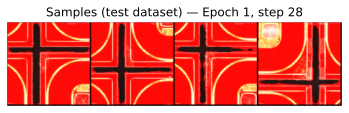

Saved new best checkpoint at epoch 1


Train epoch 2:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 2:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2/35 train_loss=0.0544 val_loss=0.1164 lr=2.98e-04


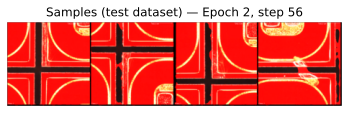

Saved new best checkpoint at epoch 2


Train epoch 3:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 3:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 3/35 train_loss=0.0511 val_loss=0.5404 lr=2.95e-04


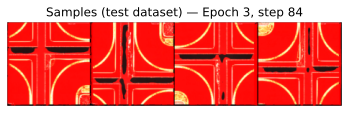

Train epoch 4:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 4:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 4/35 train_loss=0.0456 val_loss=0.1248 lr=2.90e-04


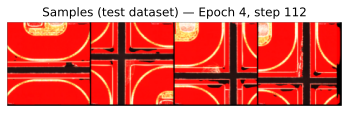

Train epoch 5:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 5:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 5/35 train_loss=0.0400 val_loss=0.1354 lr=2.85e-04


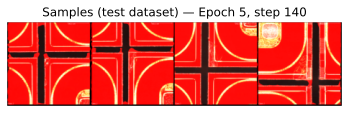

Train epoch 6:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 6:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 6/35 train_loss=0.0372 val_loss=0.0733 lr=2.79e-04


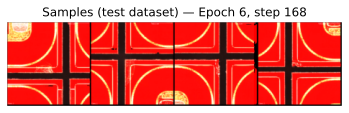

Saved new best checkpoint at epoch 6


Train epoch 7:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 7:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 7/35 train_loss=0.0333 val_loss=0.0916 lr=2.71e-04


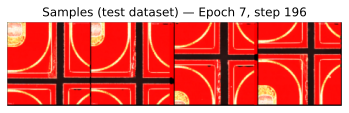

Train epoch 8:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 8:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 8/35 train_loss=0.0348 val_loss=0.0482 lr=2.63e-04


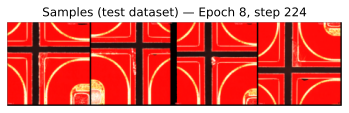

Saved new best checkpoint at epoch 8


Train epoch 9:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 9:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 9/35 train_loss=0.0395 val_loss=0.0695 lr=2.54e-04


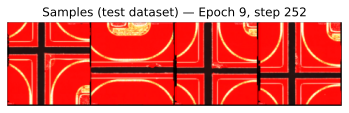

Train epoch 10:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 10:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 10/35 train_loss=0.0333 val_loss=0.1174 lr=2.44e-04


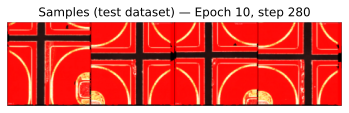

Train epoch 11:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 11:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 11/35 train_loss=0.0325 val_loss=0.1411 lr=2.33e-04


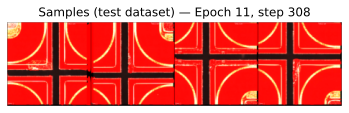

Train epoch 12:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 12:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 12/35 train_loss=0.0330 val_loss=0.0777 lr=2.21e-04


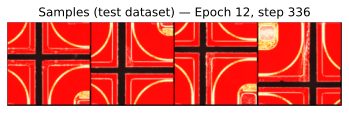

Train epoch 13:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 13:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 13/35 train_loss=0.0305 val_loss=0.1173 lr=2.09e-04


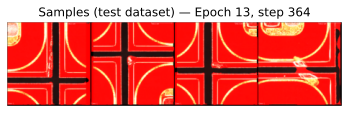

Train epoch 14:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 14:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 14/35 train_loss=0.0304 val_loss=0.1286 lr=1.96e-04


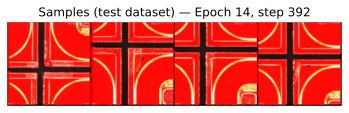

Train epoch 15:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 15:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 15/35 train_loss=0.0290 val_loss=0.0819 lr=1.83e-04


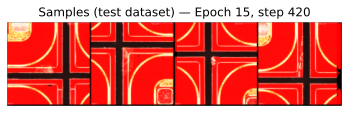

Train epoch 16:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 16:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 16/35 train_loss=0.0278 val_loss=0.1324 lr=1.70e-04


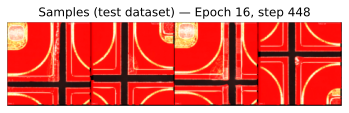

Train epoch 17:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 17:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 17/35 train_loss=0.0278 val_loss=0.1025 lr=1.57e-04


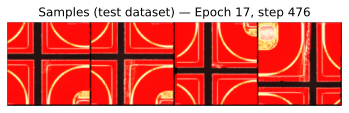

Train epoch 18:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 18:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 18/35 train_loss=0.0274 val_loss=0.0990 lr=1.43e-04


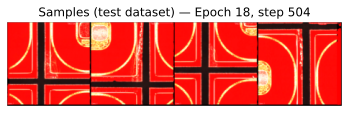

Train epoch 19:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 19:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 19/35 train_loss=0.0282 val_loss=0.0760 lr=1.30e-04


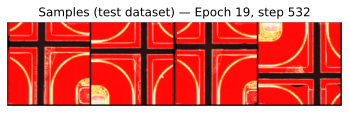

Train epoch 20:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 20:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 20/35 train_loss=0.0271 val_loss=0.0576 lr=1.17e-04


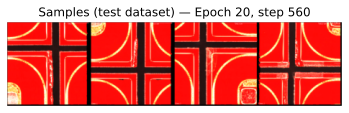

Train epoch 21:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 21:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 21/35 train_loss=0.0276 val_loss=0.0653 lr=1.04e-04


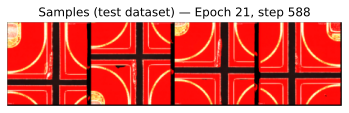

Train epoch 22:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 22:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 22/35 train_loss=0.0272 val_loss=0.0696 lr=9.10e-05


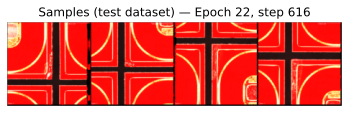

Train epoch 23:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 23:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 23/35 train_loss=0.0268 val_loss=0.0582 lr=7.89e-05


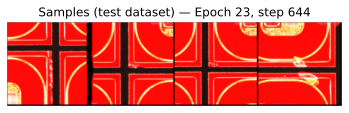

Train epoch 24:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 24:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 24/35 train_loss=0.0271 val_loss=0.0689 lr=6.74e-05


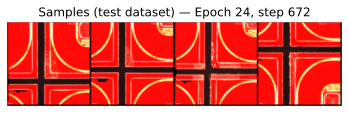

Train epoch 25:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 25:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 25/35 train_loss=0.0268 val_loss=0.0483 lr=5.65e-05


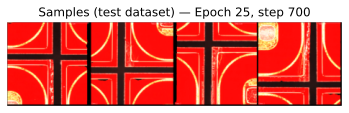

Train epoch 26:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 26:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 26/35 train_loss=0.0268 val_loss=0.0658 lr=4.63e-05


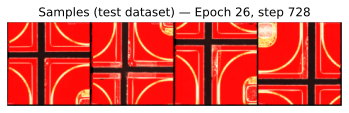

Train epoch 27:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 27:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 27/35 train_loss=0.0268 val_loss=0.0707 lr=3.70e-05


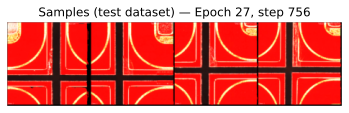

Train epoch 28:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 28:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 28/35 train_loss=0.0261 val_loss=0.0674 lr=2.86e-05


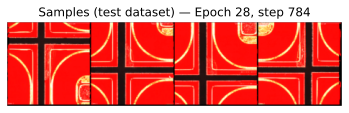

Train epoch 29:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 29:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 29/35 train_loss=0.0264 val_loss=0.0775 lr=2.12e-05


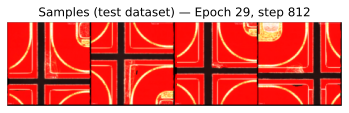

Train epoch 30:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 30/35 train_loss=0.0263 val_loss=0.0801 lr=1.49e-05


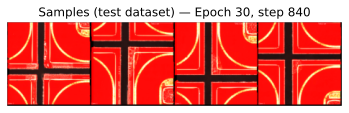

Train epoch 31:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 31:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 31/35 train_loss=0.0263 val_loss=0.0612 lr=9.56e-06


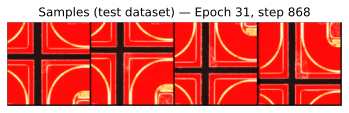

Train epoch 32:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 32:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 32/35 train_loss=0.0263 val_loss=0.0575 lr=5.41e-06


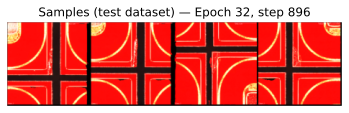

Train epoch 33:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 33:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 33/35 train_loss=0.0262 val_loss=0.0630 lr=2.41e-06


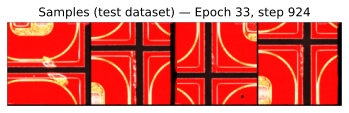

Train epoch 34:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 34:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 34/35 train_loss=0.0260 val_loss=0.0664 lr=6.04e-07


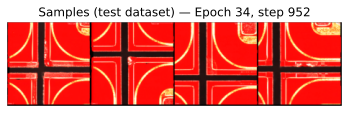

Train epoch 35:   0%|          | 0/28 [00:00<?, ?it/s]

Val epoch 35:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 35/35 train_loss=0.0262 val_loss=0.0692 lr=0.00e+00


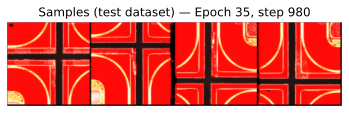

Test:   0%|          | 0/9 [00:00<?, ?it/s]

[Test] loss=0.0721


In [12]:
import random

for epoch in range(start_epoch, cfg.num_epochs):
    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
        device,
        epoch=epoch,
        log_every=cfg.log_every,
        sample_every=cfg.sample_every,  # still used inside train_one_epoch if you want
        sample_dir=cfg.sample_dir or (cfg.save_dir / "samples"),
        sample_count=cfg.sample_count,
        global_step_offset=epoch * len(train_loader),
    )

    val_loss = evaluate(model, val_loader, device, epoch=epoch, split="Val")
    lr_scheduler.step()
    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1}/{cfg.num_epochs} "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"lr={lr:.2e}"
    )

    # Append to history
    history.append(
        {
            "epoch": epoch,
            "epoch_display": epoch + 1,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "lr": float(lr),
        }
    )

    # Save history to JSON and CSV so it can be graphed later
    with history_json_path.open("w") as f:
        json.dump(history, f, indent=2)

    with history_csv_path.open("w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=["epoch", "epoch_display", "train_loss", "val_loss", "lr"],
        )
        writer.writeheader()
        writer.writerows(history)

    model.eval()
    with torch.no_grad():
        # Take a random subset of samples from the TEST dataset
        test_ds = test_loader.dataset
        n_test = len(test_ds)

        # How many to draw for visualization
        n_vis = cfg.sample_count

        # Random unique indices (if dataset is small, min ensures we don't overshoot)
        rand_indices = random.sample(range(n_test), k=min(n_vis, n_test))

        imgs_list = []
        masks_list = []
        for idx in rand_indices:
            img, mask = test_ds[idx]  # dataset returns (C,H,W) tensors
            imgs_list.append(img)
            masks_list.append(mask)

        sample_images = torch.stack(imgs_list, dim=0).to(device, non_blocking=True)
        sample_masks = torch.stack(masks_list, dim=0).to(device, non_blocking=True)

        sample_logits = model(sample_images)
        sample_preds = torch.sigmoid(sample_logits)

    # Define tag using epoch + global step at end of this epoch
    global_step = (epoch + 1) * len(train_loader)
    sample_tag = f"test_epoch{epoch+1}_step{global_step}"
    sample_out_dir = cfg.sample_dir or (cfg.save_dir / "samples")

    # Save PNGs (images / masks / preds / overlay)
    save_debug_samples(
        sample_images.detach(),
        sample_masks.detach(),
        sample_preds.detach(),
        out_dir=sample_out_dir,
        tag=sample_tag,
        max_samples=cfg.sample_count,
    )

    overlay_path = sample_out_dir / f"{sample_tag}_overlay.png"
    
#     tqdm.write( f"[Test sample] Saved TEST samples for epoch {epoch+1}, "
# f"global step {global_step} at {overlay_path}")

    # Show the overlay inline in the notebook
    try:
        img = plt.imread(overlay_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Samples (test dataset) — Epoch {epoch+1}, step {global_step}")
        plt.show()
    except FileNotFoundError:
        print(f"Could not load overlay image at {overlay_path}")

    # Checkpointing
    if val_loss < best_val:
        best_val = val_loss
        save_checkpoint(model, optimizer,  lr_scheduler, epoch, ckpt_dir / "best.pt")
        print(f"Saved new best checkpoint at epoch {epoch+1}")

# Save last checkpoint
save_checkpoint(model, optimizer, lr_scheduler, cfg.num_epochs - 1, ckpt_dir / "last.pt")

# Final test evaluation
test_loss = evaluate(model, test_loader, device, epoch=None, split="Test")
print(f"[Test] loss={test_loss:.4f}")

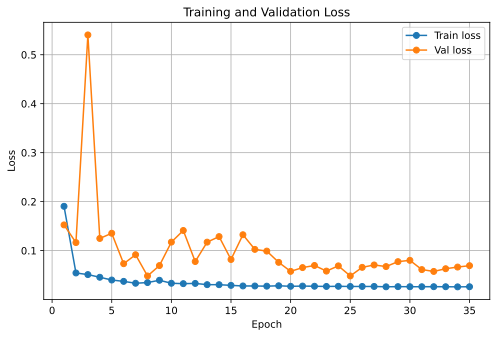

Saved loss curve to: runs/attr2unet/loss_curve.svg


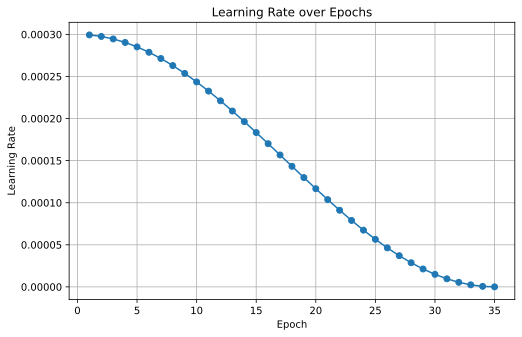

Saved LR curve to: runs/attr2unet/lr_curve.svg


In [13]:
# If you start a fresh notebook later, you can reload history with:
# with open(history_json_path) as f:
#     history = json.load(f)

epochs = [h["epoch_display"] for h in history]
train_losses = [h["train_loss"] for h in history]
val_losses = [h["val_loss"] for h in history]
lrs = [h["lr"] for h in history]

# 1) Train vs Val loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Train loss")
plt.plot(epochs, val_losses, marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
loss_svg_path = ckpt_dir / "loss_curve.svg"
plt.savefig(loss_svg_path, format="svg", bbox_inches="tight")
plt.show()
print("Saved loss curve to:", loss_svg_path)

# 2) Learning rate schedule
plt.figure(figsize=(8, 5))
plt.plot(epochs, lrs, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate over Epochs")
plt.grid(True)
lr_svg_path = ckpt_dir / "lr_curve.svg"
plt.savefig(lr_svg_path, format="svg", bbox_inches="tight")
plt.show()
print("Saved LR curve to:", lr_svg_path)

## DEMO & accuracy w/ test dataset \(unseen\)

### Helper methods for demo

In [14]:
import time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


def evaluate_segmentation_with_metrics(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    max_batches: int | None = None,
    eps: float = 1e-7,
) -> dict:
    """
    Evaluate a binary segmentation model on `loader` and return
    loss + pixel-wise metrics.
    """
    model.eval()
    total_loss = 0.0
    total_pixels = 0

    tp = tn = fp = fn = 0  # pixel-wise counts

    with torch.no_grad():
        for b, (images, masks) in enumerate(loader):
            if max_batches is not None and b >= max_batches:
                break

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.sigmoid(logits)

            # Same loss as training: BCE + Dice
            bce = F.binary_cross_entropy_with_logits(logits, masks)
            dloss = dice_loss(probs, masks)
            loss = bce + dloss
            total_loss += loss.item() * images.size(0)

            # Threshold to 0/1
            preds = (probs > 0.5).float()

            # Flatten for counting
            preds_flat = preds.view(-1)
            targets_flat = masks.view(-1)

            tp += ((preds_flat == 1) & (targets_flat == 1)).sum().item()
            tn += ((preds_flat == 0) & (targets_flat == 0)).sum().item()
            fp += ((preds_flat == 1) & (targets_flat == 0)).sum().item()
            fn += ((preds_flat == 0) & (targets_flat == 1)).sum().item()

            total_pixels += preds_flat.numel()

    avg_loss = total_loss / len(loader.dataset)

    acc = (tp + tn) / (total_pixels + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    dice = 2 * tp / (2 * tp + fp + fn + eps)

    return {
        "loss": float(avg_loss),
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "iou": float(iou),
        "dice": float(dice),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "pixels": int(total_pixels),
    }


def show_test_samples_with_overlay(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    demo_count: int = 4,
    title_prefix: str = "Device",
):
    """
    Take one batch from `loader`, run inference,
    and show Original | GT | Pred | Overlay | Masked.
    """
    model.eval()
    with torch.no_grad():
        images, masks = next(iter(loader))
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds_bin = (probs > 0.5).float()

    # Move to CPU for plotting
    imgs = images[:demo_count].cpu()
    gts = masks[:demo_count].cpu()
    preds = preds_bin[:demo_count].cpu()

    fig, axes = plt.subplots(demo_count, 5, figsize=(18, 3 * demo_count))
    if demo_count == 1:
        axes = axes.reshape(1, 5)

    for i in range(demo_count):
        img = imgs[i]  # (C, H, W)

        # ----- 1) Original image -----
        if img.shape[0] == 1:
            img_disp = img.squeeze(0)
            axes[i, 0].imshow(img_disp, cmap="gray")
        else:
            img_disp = img.permute(1, 2, 0).clamp(0, 1)
            axes[i, 0].imshow(img_disp)
        axes[i, 0].set_title(f"{title_prefix} - Image {i}")
        axes[i, 0].axis("off")

        # ----- 2) Ground-truth mask -----
        gt = gts[i]
        axes[i, 1].imshow(gt.squeeze(0), cmap="gray")
        axes[i, 1].set_title("GT mask")
        axes[i, 1].axis("off")

        # ----- 3) Predicted mask -----
        pred = preds[i]
        axes[i, 2].imshow(pred.squeeze(0), cmap="gray")
        axes[i, 2].set_title("Pred mask")
        axes[i, 2].axis("off")

        # ----- 4) Overlay: image + red prediction -----
        if img.shape[0] == 1:
            base = img.repeat(3, 1, 1)
        else:
            base = img.clone()
        base = base.clamp(0, 1)

        mask = pred.squeeze(0)  # (H, W)
        overlay = base.clone()
        overlay[0] = torch.clamp(overlay[0] + mask, 0, 1)  # boost red
        overlay_disp = overlay.permute(1, 2, 0)

        axes[i, 3].imshow(overlay_disp)
        axes[i, 3].set_title("Overlay (pred)")
        axes[i, 3].axis("off")

        # ----- 5) Masked image: original * pred -----
        masked = base * mask.unsqueeze(0)  # (3, H, W)
        masked_disp = masked.permute(1, 2, 0).clamp(0, 1)
        axes[i, 4].imshow(masked_disp)
        axes[i, 4].set_title("Masked (img × pred)")
        axes[i, 4].axis("off")

    plt.tight_layout()
    plt.show()

### Demo w/ accuracy & GPU vs CPU benchmark

Loading best checkpoint from: runs/attr2unet/best.pt
Best checkpoint epoch in file: 8

=== GPU Inference (cuda:0) with best.pt ===
Time: 3.173 s for 65 images (20.49 img/s)
Metrics (GPU, best.pt): loss=0.0487, acc=0.9892, iou=0.9868, dice=0.9933, precision=0.9949, recall=0.9918, f1=0.9933

GPU sample predictions (best.pt):


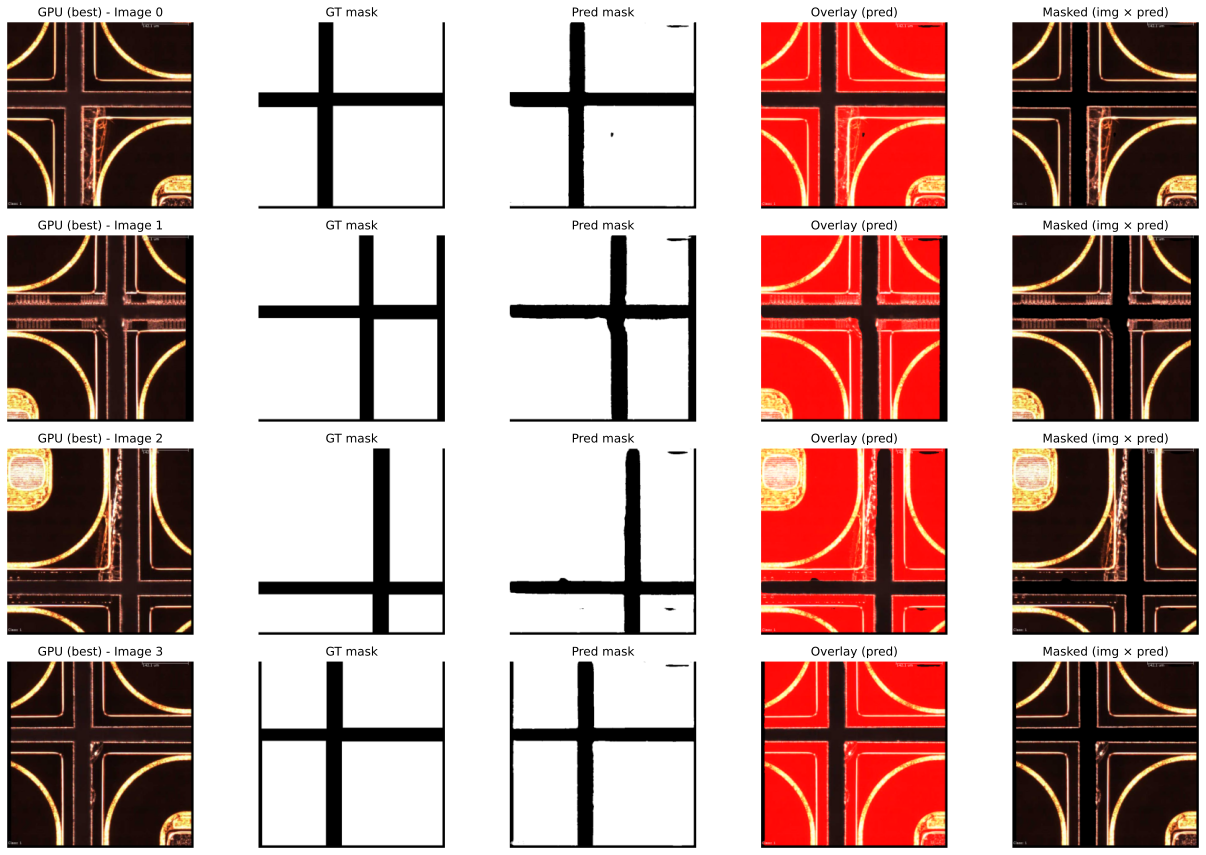


Saved benchmark to: runs/attr2unet/inference_benchmark_best.json


In [15]:
from pathlib import Path
import time
import torch

# Parameters
model_path_root = Path("runs")
target_model: ModelName = "attr2unet"
best_weight_name = "best.pt"

# Load BEST checkpoint from runs/attr2unet/best.pt
best_ckpt_path = model_path_root / target_model / best_weight_name

if not best_ckpt_path.is_file():
    raise FileNotFoundError(f"Best checkpoint not found at {best_ckpt_path}")

print(f"Loading best checkpoint from: {best_ckpt_path}")
checkpoint = torch.load(best_ckpt_path, map_location="cpu")
best_state = checkpoint["model_state"]
best_epoch = checkpoint.get("epoch", None)
if best_epoch is not None:
    print(f"Best checkpoint epoch in file: {best_epoch + 1}")
print()

results = {}

# Load test_loader
_, _, test_loader = get_dataloaders(cfg)

# --------------------------------------------------
# 1. GPU benchmark (if available) with best weights
# --------------------------------------------------
if True:        # toggle GPU bench
    if torch.cuda.is_available():
        device_gpu = torch.device("cuda:0")
        print("=== GPU Inference (cuda:0) with best.pt ===")

        # Fresh model on GPU, load BEST weights
        model_gpu = build_model(cfg).to(device_gpu)
        model_gpu.load_state_dict(best_state)

        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        start_gpu = time.perf_counter()

        metrics_gpu = evaluate_segmentation_with_metrics(
            model_gpu,
            test_loader,
            device_gpu,
            max_batches=None,  # set to e.g. 10 for faster testing
        )

        torch.cuda.synchronize()
        elapsed_gpu = time.perf_counter() - start_gpu

        num_images = len(test_loader.dataset)
        imgs_per_sec_gpu = num_images / elapsed_gpu

        results["gpu"] = {
            "device": str(device_gpu),
            "time_sec": elapsed_gpu,
            "images": num_images,
            "images_per_sec": imgs_per_sec_gpu,
            "metrics": metrics_gpu,
        }

        print(f"Time: {elapsed_gpu:.3f} s for {num_images} images "
            f"({imgs_per_sec_gpu:.2f} img/s)")
        print(
            "Metrics (GPU, best.pt): "
            f"loss={metrics_gpu['loss']:.4f}, "
            f"acc={metrics_gpu['accuracy']:.4f}, "
            f"iou={metrics_gpu['iou']:.4f}, "
            f"dice={metrics_gpu['dice']:.4f}, "
            f"precision={metrics_gpu['precision']:.4f}, "
            f"recall={metrics_gpu['recall']:.4f}, "
            f"f1={metrics_gpu['f1']:.4f}"
        )

        print("\nGPU sample predictions (best.pt):")
        show_test_samples_with_overlay(
            model_gpu,
            test_loader,
            device_gpu,
            demo_count=4,
            title_prefix="GPU (best)",
        )
        print()

    else:
        print("No CUDA device available, skipping GPU benchmark.")


# --------------------------------------------------
# 2. CPU benchmark with best weights
# --------------------------------------------------
if False:       # toggle CPU bench
    device_cpu = torch.device("cpu")
    print("=== CPU Inference (cpu) with best.pt ===")

    model_cpu = build_model(cfg).to(device_cpu)
    model_cpu.load_state_dict(best_state)

    start_cpu = time.perf_counter()

    metrics_cpu = evaluate_segmentation_with_metrics(
        model_cpu,
        test_loader,
        device_cpu,
        max_batches=None,  # set to e.g. 10 if you want it faster
    )

    elapsed_cpu = time.perf_counter() - start_cpu
    num_images = len(test_loader.dataset)
    imgs_per_sec_cpu = num_images / elapsed_cpu

    results["cpu"] = {
        "device": str(device_cpu),
        "time_sec": elapsed_cpu,
        "images": num_images,
        "images_per_sec": imgs_per_sec_cpu,
        "metrics": metrics_cpu,
    }

    print(f"Time: {elapsed_cpu:.3f} s for {num_images} images "
        f"({imgs_per_sec_cpu:.2f} img/s)")
    print(
        "Metrics (CPU, best.pt): "
        f"loss={metrics_cpu['loss']:.4f}, "
        f"acc={metrics_cpu['accuracy']:.4f}, "
        f"iou={metrics_cpu['iou']:.4f}, "
        f"dice={metrics_cpu['dice']:.4f}, "
        f"precision={metrics_cpu['precision']:.4f}, "
        f"recall={metrics_cpu['recall']:.4f}, "
        f"f1={metrics_cpu['f1']:.4f}"
    )

    print("\nCPU sample predictions (best.pt):")
    show_test_samples_with_overlay(
        model_cpu,
        test_loader,
        device_cpu,
        demo_count=4,
        title_prefix="CPU (best)",
    )

# Optional: save benchmark results for later comparison
bench_path = model_path_root / target_model / "inference_benchmark_best.json"
with bench_path.open("w") as f:
    json.dump(results, f, indent=2)
print("Saved benchmark to:", bench_path)